t=0.000  lam_min=-0.341663 [UNSTABLE] | r_rms=0.15017 r_infL2=0.85286 r_infF=0.60306 | C2(rr)=6.898 D1(rr)=1.036
t=0.025  lam_min=-0.279576 [UNSTABLE] | r_rms=0.13968 r_infL2=0.80998 r_infF=0.57274 | C2(rr)=6.912 D1(rr)=0.966
t=0.050  lam_min=-0.225652 [UNSTABLE] | r_rms=0.13055 r_infL2=0.77005 r_infF=0.54451 | C2(rr)=6.858 D1(rr)=0.895
t=0.075  lam_min=-0.182334 [UNSTABLE] | r_rms=0.12263 r_infL2=0.73293 r_infF=0.51826 | C2(rr)=6.812 D1(rr)=0.835
t=0.100  lam_min=-0.141215 [UNSTABLE] | r_rms=0.11578 r_infL2=0.69851 r_infF=0.49392 | C2(rr)=6.620 D1(rr)=0.766
t=0.125  lam_min=-0.111079 [UNSTABLE] | r_rms=0.10987 r_infL2=0.66664 r_infF=0.47138 | C2(rr)=6.519 D1(rr)=0.716
t=0.150  lam_min=-0.082733 [UNSTABLE] | r_rms=0.10477 r_infL2=0.63715 r_infF=0.45053 | C2(rr)=6.309 D1(rr)=0.661
t=0.175  lam_min=-0.054300 [UNSTABLE] | r_rms=0.10037 r_infL2=0.60990 r_infF=0.43126 | C2(rr)=5.933 D1(rr)=0.595
t=0.200  lam_min=-0.034581 [UNSTABLE] | r_rms=0.09658 r_infL2=0.58473 r_infF=0.41347 | C2(rr)=5.

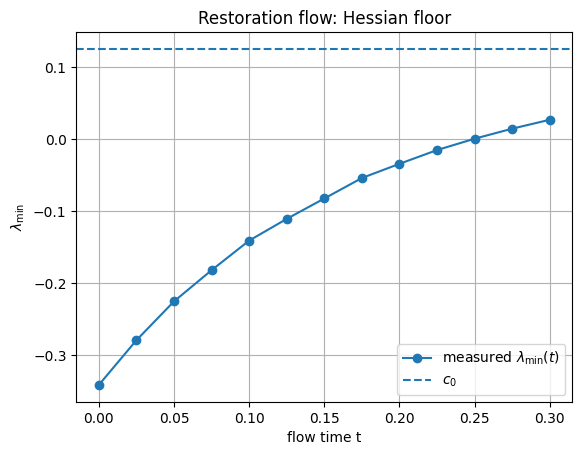

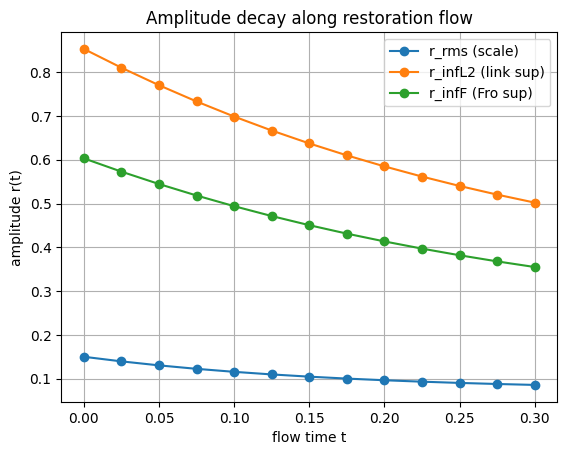

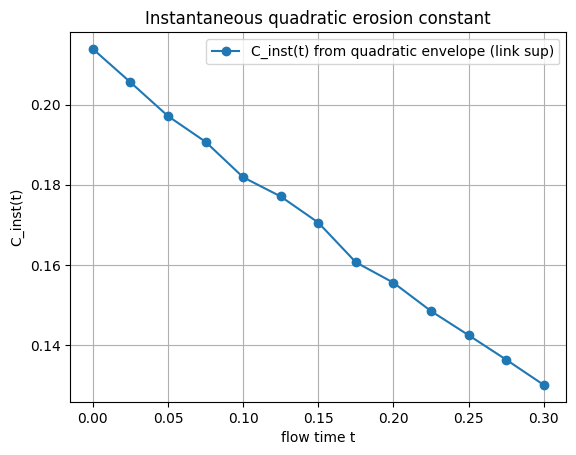

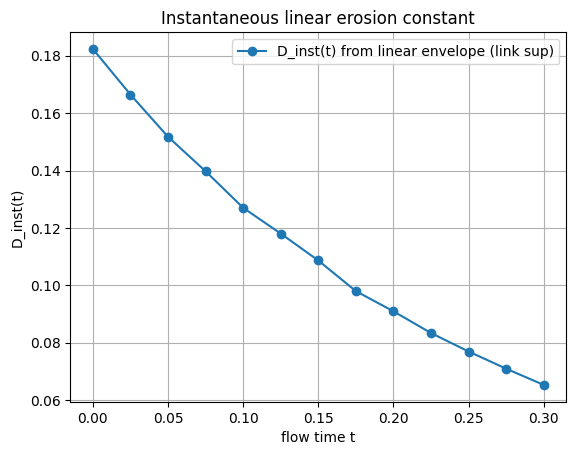

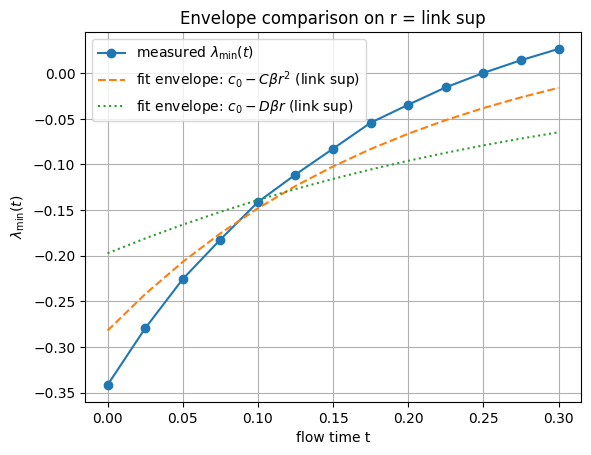


=== Rough contraction rates (2nd half log-linear fit) ===
gamma_rms   ~ 1.318583520389626
gamma_infL2 ~ 1.5891052355925226
gamma_infF  ~ 1.589105235592522


In [1]:
# ============================================================
# Dynamic restoration flow: log r_t and fit erosion envelopes
#   lambda_min(t) ~ c0 - C*beta*r(t)^2   (quadratic)
#   lambda_min(t) ~ c0 - D*beta*r(t)     (linear)
#
# Works in a fresh Colab with JAX installed (GPU recommended).
# ============================================================

import os, math, time, warnings
warnings.filterwarnings("ignore", message="Casting complex values to real discards the imaginary part")

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

# ---------------------------
# USER KNOBS (start here)
# ---------------------------
jax.config.update("jax_enable_x64", True)   # True = nicer numerics, slower; False = faster
PRINT_EVERY = 1

L = 8                   # lattice linear size, 4D torus
beta = 3.0              # coupling
c0   = 0.125            # Haar convexity floor (as in your scans)
dt   = 0.005            # flow step
n_steps = 60            # total GD steps; flow time = n_steps*dt

init_scale = 0.15       # Gaussian init in "scale_rms" units (componentwise std)
seed = 0

measure_every = 5       # compute diagnostics every N steps (reduces cost)
lanczos_m = 22          # Lanczos iterations for lambda_min (20-30 typical)
lanczos_key_seed = 123  # fixed seed so lambda_min estimates are reproducible

USE_PADE22_EXPM = True  # True = fast, unitary (2,2) Padé; False = jax.scipy.linalg.expm (slower)

# ------------------------------------------------------------
# SU(3) generators: T_a = i * lambda_a / 2 (anti-Hermitian)
# Normalization: Tr(T_a T_b) = -1/2 delta_ab
# => Frobenius norm of A = sum a_a T_a is ||A||_F = ||a||_2 / sqrt(2)
# ------------------------------------------------------------
def su3_T():
    z = 0.0 + 0.0j
    one = 1.0 + 0.0j
    lam = []
    lam.append(jnp.array([[0,1,0],[1,0,0],[0,0,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[0,-1j,0],[1j,0,0],[0,0,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[1,0,0],[0,-1,0],[0,0,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[0,0,1],[0,0,0],[1,0,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[0,0,-1j],[0,0,0],[1j,0,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[0,0,0],[0,0,1],[0,1,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[0,0,0],[0,0,-1j],[0,1j,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[1,0,0],[0,1,0],[0,0,-2]], dtype=jnp.complex128)/jnp.sqrt(3.0))
    # anti-Hermitian generators
    T = [1j*L_/2.0 for L_ in lam]
    return jnp.stack(T, axis=0)  # (8,3,3)

T8 = su3_T()

def A_from_coords(a8):
    # a8 shape (...,8) real -> A shape (...,3,3) complex anti-Hermitian
    # A = sum_a a_a T_a
    return jnp.tensordot(a8, T8, axes=([a8.ndim-1],[0]))

def dagger(U):
    return jnp.swapaxes(jnp.conj(U), -1, -2)

# ------------------------------------------------------------
# Exponential map
# Padé(2,2): R(A) = (I + A/2 + A^2/12) (I - A/2 + A^2/12)^{-1}
# For anti-Hermitian A, this is exactly unitary (good for numerics).
# ------------------------------------------------------------
if not USE_PADE22_EXPM:
    from jax.scipy.linalg import expm as jax_expm

def exp_su3(A):
    # A shape (...,3,3) complex
    if not USE_PADE22_EXPM:
        return jax_expm(A)
    I = jnp.eye(3, dtype=A.dtype)
    A2 = A @ A
    P = I + 0.5*A + (1.0/12.0)*A2
    Q = I - 0.5*A + (1.0/12.0)*A2
    # solve Q X = P  -> X = Q^{-1} P
    return jnp.linalg.solve(Q, P)

v_expm = jax.vmap(exp_su3, in_axes=0, out_axes=0)

# ------------------------------------------------------------
# Lattice helpers
# theta has shape (V,4,8) where V=L^4
# ------------------------------------------------------------
V = L**4
def theta_to_links(theta):
    # theta: (V,4,8) -> U: (L,L,L,L,4,3,3)
    A = A_from_coords(theta)               # (V,4,3,3)
    Aflat = A.reshape((-1,3,3))            # (V*4,3,3)
    Uflat = v_expm(Aflat)                  # (V*4,3,3)
    U = Uflat.reshape((V,4,3,3)).reshape((L,L,L,L,4,3,3))
    return U

def shift_site(X, mu, step=1):
    # X: (L,L,L,L,...) shift forward in +mu direction
    # roll by -step means x -> x+step e_mu
    return jnp.roll(X, shift=-step, axis=mu)

# ------------------------------------------------------------
# Wilson action (sum over plaquettes) and Haar quadratic mass
# ------------------------------------------------------------
def wilson_action(theta):
    U = theta_to_links(theta)  # (L,L,L,L,4,3,3)
    S = 0.0
    for mu in range(4):
        for nu in range(mu+1, 4):
            U_mu = U[..., mu, :, :]
            U_nu = U[..., nu, :, :]
            U_nu_xpmu = shift_site(U_nu, mu, 1)     # U_nu(x+mu)
            U_mu_xpnu = shift_site(U_mu, nu, 1)     # U_mu(x+nu)
            P = U_mu @ U_nu_xpmu @ dagger(U_mu_xpnu) @ dagger(U_nu)
            trP = jnp.trace(P, axis1=-2, axis2=-1)
            S += jnp.sum(1.0 - jnp.real(trP)/3.0)
    return S

def haar_quadratic(theta):
    # Choose it so Hessian at 0 is exactly c0 * I in theta-coordinates
    return 0.5 * c0 * jnp.sum(theta**2)

def total_action(theta):
    return beta * wilson_action(theta) + haar_quadratic(theta)

# grad and hvp
grad_S = jax.jit(jax.grad(total_action))

def hvp(theta, v):
    # Hess(theta) @ v = d/dε grad(theta + ε v)|_0
    return jax.jvp(grad_S, (theta,), (v,))[1]

hvp_jit = jax.jit(hvp)

# ------------------------------------------------------------
# Lanczos (device-side) for minimum eigenvalue estimate
# ------------------------------------------------------------
def tree_dot(x, y):
    return jnp.sum(x*y)

def tree_norm(x):
    return jnp.sqrt(tree_dot(x,x) + 1e-30)

@jax.jit
def lanczos_min_eig(theta, key, m=lanczos_m):
    # returns approx min eigenvalue of Hessian at theta
    q0 = jax.random.normal(key, shape=theta.shape, dtype=theta.dtype)
    q0 = q0 / tree_norm(q0)

    def body(carry, _):
        q_prev, q, beta_prev = carry
        z = hvp_jit(theta, q)
        z = z - beta_prev * q_prev
        alpha = tree_dot(q, z)
        z = z - alpha * q
        beta = tree_norm(z)
        q_next = z / (beta + 1e-30)
        return (q, q_next, beta), (alpha, beta)

    init = (jnp.zeros_like(q0), q0, jnp.array(0.0, dtype=theta.dtype))
    (q_last, q_next, beta_last), (alphas, betas) = jax.lax.scan(body, init, xs=None, length=m)

    # Build tridiagonal T (m x m): diag=alphas, offdiag=betas[:-1]
    T = jnp.diag(alphas)
    off = betas[:-1]
    T = T + jnp.diag(off, 1) + jnp.diag(off, -1)

    evals = jnp.linalg.eigvalsh(T)
    return evals[0]

# ------------------------------------------------------------
# r-statistics (your "decide the correct r" step)
# ------------------------------------------------------------
@jax.jit
def r_scale_rms(theta):
    # RMS over all coordinates (matches your "scale" notion)
    return jnp.sqrt(jnp.mean(theta**2) + 1e-30)

@jax.jit
def r_linkL2_inf(theta):
    # max over links of L2 norm in coordinate space
    # theta shape (V,4,8) -> link norms (V,4)
    ln = jnp.sqrt(jnp.sum(theta**2, axis=-1) + 1e-30)
    return jnp.max(ln)

@jax.jit
def r_fro_inf_from_coords(theta):
    # Using Tr(T_a T_b) = -1/2 delta_ab => ||A||_F = ||a||_2 / sqrt(2)
    return r_linkL2_inf(theta) / jnp.sqrt(2.0)

# ------------------------------------------------------------
# One GD step (restoration flow)
# ------------------------------------------------------------
@jax.jit
def flow_step(theta):
    return theta - dt * grad_S(theta)

# ------------------------------------------------------------
# Run flow + log diagnostics
# ------------------------------------------------------------
key = jax.random.PRNGKey(seed)
theta0 = init_scale * jax.random.normal(key, shape=(V,4,8), dtype=jnp.float64 if jax.config.read("jax_enable_x64") else jnp.float32)

log_t = []
log_lam = []
log_r_rms = []
log_r_infL2 = []
log_r_infF = []

log_C2_rms = []
log_C2_infL2 = []
log_C2_infF = []
log_D1_rms = []
log_D1_infL2 = []
log_D1_infF = []

t0 = time.time()
theta = theta0
lkey = jax.random.PRNGKey(lanczos_key_seed)

for n in range(n_steps+1):
    if n % measure_every == 0:
        t = n * dt
        # fresh lanczos key per measurement
        lkey, subk = jax.random.split(lkey)
        lam_min = float(lanczos_min_eig(theta, subk))

        rr  = float(r_scale_rms(theta))
        rL2 = float(r_linkL2_inf(theta))
        rF  = float(r_fro_inf_from_coords(theta))

        y = (c0 - lam_min) / beta  # y ~ C r^2 or y ~ D r

        eps = 1e-30
        C2_rr  = y / (rr*rr + eps)
        C2_L2  = y / (rL2*rL2 + eps)
        C2_F   = y / (rF*rF + eps)
        D1_rr  = y / (rr + eps)
        D1_L2  = y / (rL2 + eps)
        D1_F   = y / (rF + eps)

        log_t.append(t)
        log_lam.append(lam_min)
        log_r_rms.append(rr)
        log_r_infL2.append(rL2)
        log_r_infF.append(rF)

        log_C2_rms.append(C2_rr)
        log_C2_infL2.append(C2_L2)
        log_C2_infF.append(C2_F)
        log_D1_rms.append(D1_rr)
        log_D1_infL2.append(D1_L2)
        log_D1_infF.append(D1_F)

        if PRINT_EVERY and (len(log_t) % PRINT_EVERY == 0):
            status = "RESTORED" if lam_min > 0 else "UNSTABLE"
            print(f"t={t:0.3f}  lam_min={lam_min:+.6f} [{status}]"
                  f" | r_rms={rr:.5f} r_infL2={rL2:.5f} r_infF={rF:.5f}"
                  f" | C2(rr)={C2_rr:.3f} D1(rr)={D1_rr:.3f}")

    if n < n_steps:
        theta = flow_step(theta)

wall = time.time() - t0
print("\nDone. (wall time depends on device / settings)")
print("Last: t, lam_min, r_rms =", log_t[-1], log_lam[-1], log_r_rms[-1])

# ------------------------------------------------------------
# Fit quality: y=(c0-lam)/beta vs r or r^2
# Decide which model stabilizes (linear vs quadratic) for each r-definition.
# ------------------------------------------------------------
t = np.array(log_t)
lam = np.array(log_lam)
rr = np.array(log_r_rms)
rL2 = np.array(log_r_infL2)
rF  = np.array(log_r_infF)

y = (c0 - lam) / beta

def fit_slope(x, y):
    # y ≈ s x through origin
    s = float(np.dot(x,y) / (np.dot(x,x) + 1e-30))
    yhat = s * x
    ss_res = float(np.sum((y - yhat)**2))
    ss_tot = float(np.sum((y - np.mean(y))**2) + 1e-30)
    r2 = 1.0 - ss_res/ss_tot
    return s, r2

def tail_stats(arr, frac=0.5):
    k0 = int(len(arr)*frac)
    tail = arr[k0:]
    med = float(np.median(tail))
    mad = float(np.median(np.abs(tail - med)) + 1e-30)
    return med, mad

# Fit for each r-definition
for name, r in [("r_rms (scale)", rr), ("r_infL2 (link sup)", rL2), ("r_infF (Fro sup)", rF)]:
    C_hat, R2C = fit_slope(r**2, y)
    D_hat, R2D = fit_slope(r,    y)

    Cinst = y / (r**2 + 1e-30)
    Dinst = y / (r    + 1e-30)

    C_med, C_mad = tail_stats(Cinst, frac=0.5)
    D_med, D_mad = tail_stats(Dinst, frac=0.5)

    print("\n==============================")
    print(f"Metric: {name}")
    print(f"Quadratic fit: y~C r^2  => C_hat={C_hat:.6g},  R^2={R2C:.4f},  tail median±MAD={C_med:.6g}±{C_mad:.3g}")
    print(f"Linear fit:    y~D r    => D_hat={D_hat:.6g},  R^2={R2D:.4f},  tail median±MAD={D_med:.6g}±{D_mad:.3g}")

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
plt.figure()
plt.plot(t, lam, 'o-', label=r"measured $\lambda_{\min}(t)$")
plt.axhline(c0, linestyle='--', label=r"$c_0$")
plt.xlabel("flow time t"); plt.ylabel(r"$\lambda_{\min}$")
plt.title("Restoration flow: Hessian floor")
plt.grid(True); plt.legend(); plt.show()

plt.figure()
plt.plot(t, rr,  'o-', label="r_rms (scale)")
plt.plot(t, rL2, 'o-', label="r_infL2 (link sup)")
plt.plot(t, rF,  'o-', label="r_infF (Fro sup)")
plt.xlabel("flow time t"); plt.ylabel("amplitude r(t)")
plt.title("Amplitude decay along restoration flow")
plt.grid(True); plt.legend(); plt.show()

# Show stabilization diagnostics for BOTH models on one chosen metric:
# choose link sup (most theorem-relevant)
Cinst = y / (rL2**2 + 1e-30)
Dinst = y / (rL2    + 1e-30)

plt.figure()
plt.plot(t, Cinst, 'o-', label="C_inst(t) from quadratic envelope (link sup)")
plt.xlabel("flow time t"); plt.ylabel("C_inst(t)")
plt.title("Instantaneous quadratic erosion constant")
plt.grid(True); plt.legend(); plt.show()

plt.figure()
plt.plot(t, Dinst, 'o-', label="D_inst(t) from linear envelope (link sup)")
plt.xlabel("flow time t"); plt.ylabel("D_inst(t)")
plt.title("Instantaneous linear erosion constant")
plt.grid(True); plt.legend(); plt.show()

# Optional: compare envelopes on the chosen r (link sup), using fitted constants
C_hat, _ = fit_slope(rL2**2, y)
D_hat, _ = fit_slope(rL2,    y)

env_quad = c0 - beta * C_hat * (rL2**2)
env_lin  = c0 - beta * D_hat * (rL2)

plt.figure()
plt.plot(t, lam, 'o-', label=r"measured $\lambda_{\min}(t)$")
plt.plot(t, env_quad, '--', label=r"fit envelope: $c_0 - C\beta r^2$ (link sup)")
plt.plot(t, env_lin,  ':',  label=r"fit envelope: $c_0 - D\beta r$ (link sup)")
plt.xlabel("flow time t"); plt.ylabel(r"$\lambda_{\min}(t)$")
plt.title("Envelope comparison on r = link sup")
plt.grid(True); plt.legend(); plt.show()

# Rough contraction rate gamma from r(t) ~ exp(-gamma t) (fit on second half)
def fit_gamma(t, r):
    k0 = len(t)//2
    tt = t[k0:]
    rr = r[k0:]
    rr = np.maximum(rr, 1e-30)
    A = np.vstack([tt, np.ones_like(tt)]).T
    slope, intercept = np.linalg.lstsq(A, np.log(rr), rcond=None)[0]
    gamma = -slope
    return float(gamma)

print("\n=== Rough contraction rates (2nd half log-linear fit) ===")
print("gamma_rms   ~", fit_gamma(t, rr))
print("gamma_infL2 ~", fit_gamma(t, rL2))
print("gamma_infF  ~", fit_gamma(t, rF))
